## Model Training:

- Required packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

- Loading Dataset

In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Changing Data Type

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
cols=['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']
df[cols] = df[cols].astype('object')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Separating 'Response' and 'Predictor' variables

In [6]:
x = df.drop('math_score',axis=1)
x

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [7]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

### Transformation and preprocessing:

In [11]:
numeric_feature = x.select_dtypes(exclude='object').columns
categorical_feature = x.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transform = StandardScaler()
oh_transform = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transform, categorical_feature),
        ('StandardScaler', numeric_transform, numeric_feature),
    ]
)

### Train Test Split:

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 7), (200, 7))

In [13]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### Creating Evaluation function to get all metrics together after model training.

In [18]:
def evaluate_model(true,predicted):
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    mae = mean_absolute_error(true,predicted)
    R2_score = r2_score(true,predicted)
    return rmse, mae, R2_score

#### Model training and evaluating:

In [21]:
models = {
    'Linear regression': LinearRegression(),
    'Ridge regression': Ridge(),
    'Lasso regression': Lasso(),
    'K Neighbors regressor': KNeighborsRegressor(),
    'Support vector regressor':SVR(),
    'Random forest regressor': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Xgboost regressor': XGBRegressor(),
    'catboost regressor': CatBoostRegressor(verbose=False)
}

model_list = []
r2_score_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse, train_mae, train_r2_score = evaluate_model(y_train, y_train_pred)
    test_rmse, test_mae, test_r2_score = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training data: ")
    print("-Root mean squared error: {:.4f}".format(train_rmse))
    print("-Mean absolute error: {:.4f}".format(train_mae))
    print("-r2_score: {:.4f}".format(train_r2_score))

    print('----------------------------------------')
    
    print("Model performance for Testing data: ")
    print("-Root mean squared error: {:.4f}".format(test_rmse))
    print("-Mean absolute error: {:.4f}".format(test_mae))
    print("-r2 score: {:.4f}".format(test_r2_score))

    r2_score_list.append(test_r2_score)

    print('='*40)
    print('\n')



Linear regression
Model performance for training data: 
-Root mean squared error: 5.3231
-Mean absolute error: 4.2667
-r2_score: 0.8743
----------------------------------------
Model performance for Testing data: 
-Root mean squared error: 5.3940
-Mean absolute error: 4.2148
-r2 score: 0.8804


Ridge regression
Model performance for training data: 
-Root mean squared error: 5.3233
-Mean absolute error: 4.2650
-r2_score: 0.8743
----------------------------------------
Model performance for Testing data: 
-Root mean squared error: 5.3904
-Mean absolute error: 4.2111
-r2 score: 0.8806


Lasso regression
Model performance for training data: 
-Root mean squared error: 6.5925
-Mean absolute error: 5.2053
-r2_score: 0.8072
----------------------------------------
Model performance for Testing data: 
-Root mean squared error: 6.5173
-Mean absolute error: 5.1557
-r2 score: 0.8254


K Neighbors regressor
Model performance for training data: 
-Root mean squared error: 5.6941
-Mean absolute error:

In [22]:
pd.DataFrame(list(zip(model_list, r2_score_list)), columns=['Model Name','R2 Score']).sort_values(by='R2 Score', ascending=False)

,Model Name,R2 Score
1,Ridge regression,0.880592
0,Linear regression,0.880433
8,catboost regressor,0.851831
5,Random forest regressor,0.851450
7,Xgboost regressor,0.827797
2,Lasso regression,0.825446
3,K Neighbors regressor,0.786089
6,Decision Tree,0.744389
4,Support vector regressor,0.729105


### Linear Regression: 

In [23]:
lin_model = LinearRegression(fit_intercept=True)
linr_model = lin_model.fit(X_train,y_train)
y_pred = linr_model.predict(X_test)
score = r2_score(y_test, y_pred)
print("Score of linear model: {:.2f}".format(score*100))

Score of linear model: 88.04


Text(0, 0.5, 'Predicted')

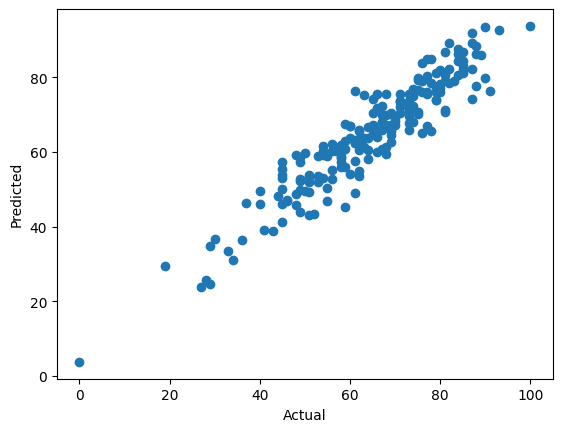

In [24]:
plt.scatter(y_test, y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted')


<Axes: xlabel='math_score'>

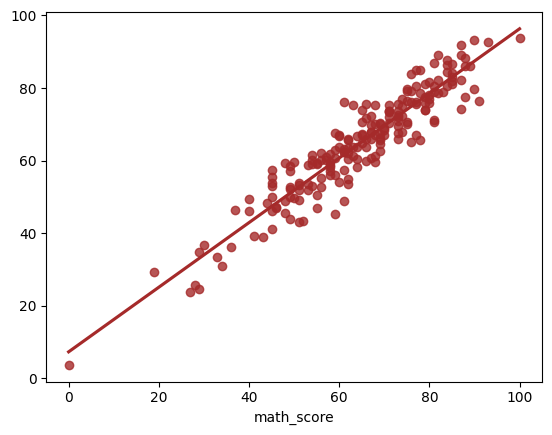

In [28]:
sns.regplot(x= y_test, y= y_pred, ci=None, color='brown')

### Difference between actual and predicted.

In [29]:
diff = pd.DataFrame({'Actual Value':y_test, 'Predicted Value':y_pred, 'Difference':y_test-y_pred})
diff

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
